# Dimensionality Reduction – PCA  
**Use Case:** Maersk Warehouse Sensor Monitoring

This demo shows how PCA helps us reduce dimensionality in high-volume sensor data collected from Maersk warehouses. We'll generate synthetic data to simulate warehouse sensor logs and use PCA to visualize the key patterns.


In [3]:
# --- Setup ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import seaborn as sns

In [4]:
# --- 1. Generate Synthetic Sensor Data (Simulating Maersk Warehouse Logs) ---

# Let's say each row is a timestamped record of 6 warehouse sensors
# The dataset includes delivery attributes like distance, traffic, weight, and time taken
df = pd.read_csv("https://raw.githubusercontent.com/saikisri97/Optimisation/master/For_AI_Lecture/data/warehouse_sensor_data.csv")

df.head()

,timestamp,temperature,humidity,vibration,CO2_level,noise_db,light_lux
0,2024-01-01 00:00:00,25.993428,51.539009,0.233144,366.656261,37.617688,234.085161
1,2024-01-01 01:00:00,24.723471,41.449158,0.258674,407.395143,38.792998,242.471244
2,2024-01-01 02:00:00,26.295377,43.259073,0.209051,414.946652,53.931348,463.984968
3,2024-01-01 03:00:00,28.046060,53.716320,0.135158,434.204471,64.576866,300.054626
4,2024-01-01 04:00:00,24.531693,50.854327,0.219984,447.416221,32.524952,362.570400


In [5]:
# --- 2. Data Preprocessing: Standardize Sensor Values ---
# We'll drop the timestamp and scale the sensor features
features = df.columns[1:]  # exclude 'timestamp'
X = df[features]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [6]:
# --- 3. Apply PCA to Reduce Dimensions to 2 Components ---
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Create a new DataFrame with principal components
df_pca = pd.DataFrame(data=X_pca, columns=['PC1', 'PC2'])

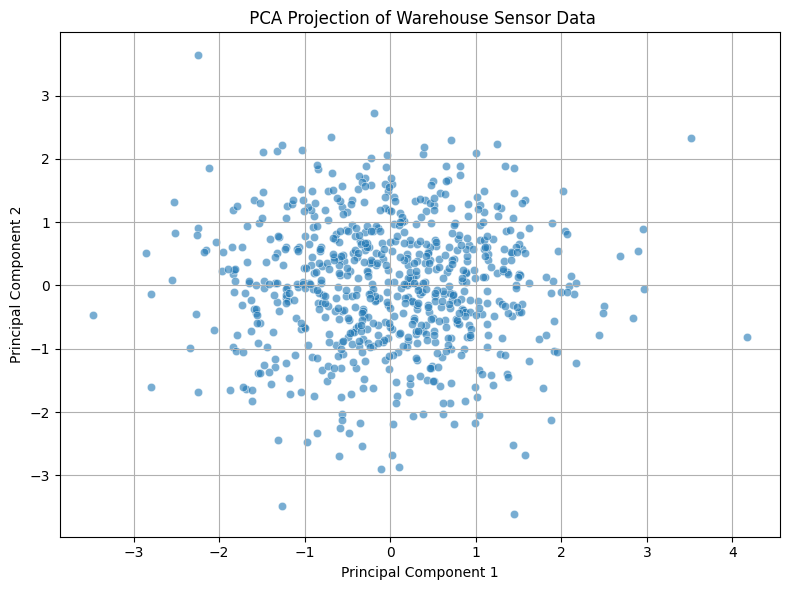

In [7]:
# --- 4. Visualize the Results: PCA Projection Plot ---
plt.figure(figsize=(8, 6))
sns.scatterplot(x='PC1', y='PC2', data=df_pca, alpha=0.6)
plt.title(' PCA Projection of Warehouse Sensor Data')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True)
plt.tight_layout()
plt.show()

In [8]:
# --- 5. Explained Variance (Optional Evaluation) ---
# Helps understand how much variance each component explains
explained_var = pca.explained_variance_ratio_
print(f"Explained Variance by PC1: {explained_var[0]:.2f}")
print(f"Explained Variance by PC2: {explained_var[1]:.2f}")

Explained Variance by PC1: 0.19
Explained Variance by PC2: 0.17


/var/folders/y2/37476f0n7c793jplk1lghrkjr8cwhw/T/ipykernel_44424/1445535081.py:16: UserWarning: Glyph 128230 (\N{PACKAGE}) missing from current font.
  plt.tight_layout()
/opt/miniconda3/envs/argos_env/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128230 (\N{PACKAGE}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


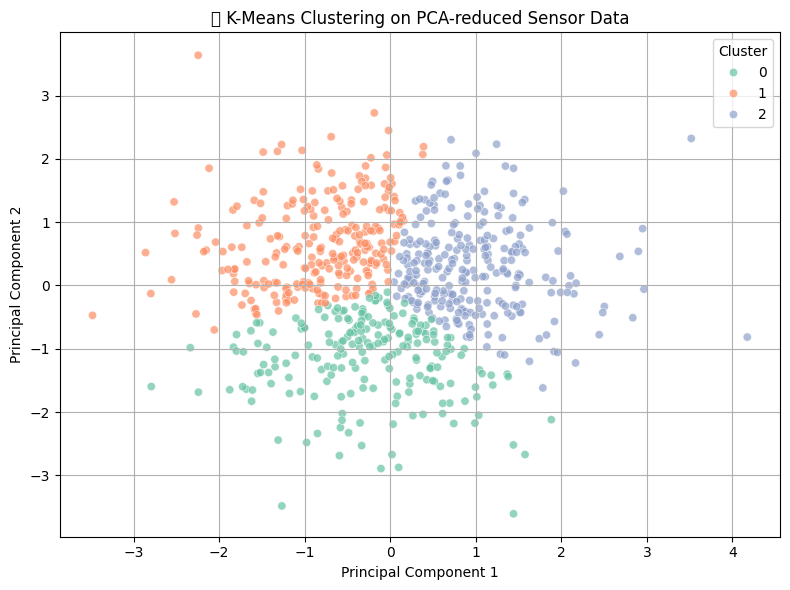

Cluster sizes:
 Cluster
2    263
1    249
0    208
Name: count, dtype: int64


In [9]:
# --- 6. Apply K-Means Clustering on PCA Result ---
from sklearn.cluster import KMeans

# We'll try clustering the PCA-reduced data into 3 groups (can be tuned)
kmeans = KMeans(n_clusters=3, random_state=42)
df_pca['Cluster'] = kmeans.fit_predict(df_pca[['PC1', 'PC2']])

# Visualize clustered PCA space
plt.figure(figsize=(8, 6))
sns.scatterplot(x='PC1', y='PC2', hue='Cluster', data=df_pca, palette='Set2', alpha=0.7)
plt.title('📦 K-Means Clustering on PCA-reduced Sensor Data')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Cluster')
plt.grid(True)
plt.tight_layout()
plt.show()

# Optional: Analyze cluster sizes
print("Cluster sizes:\n", df_pca['Cluster'].value_counts())


/var/folders/y2/37476f0n7c793jplk1lghrkjr8cwhw/T/ipykernel_44424/3697460581.py:18: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from current font.
  plt.tight_layout()
/opt/miniconda3/envs/argos_env/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


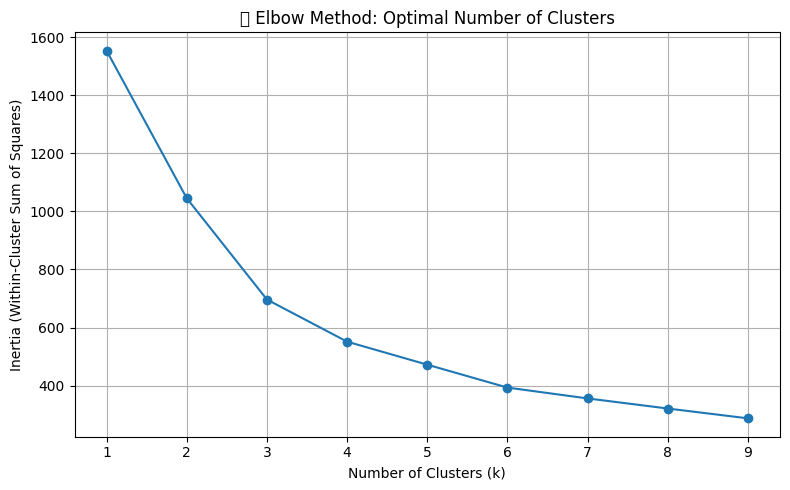

In [10]:
# --- 5.1 Elbow Method to Determine Optimal Number of Clusters ---
inertia = []
k_range = range(1, 10)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(df_pca[['PC1', 'PC2']])
    inertia.append(kmeans.inertia_)

# Plot the elbow curve
plt.figure(figsize=(8, 5))
plt.plot(k_range, inertia, marker='o')
plt.title('📈 Elbow Method: Optimal Number of Clusters')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia (Within-Cluster Sum of Squares)')
plt.grid(True)
plt.xticks(k_range)
plt.tight_layout()
plt.show()


---  
### 🛠 Optional Enhancements  
- Try 3D PCA and plot in 3D  
- Explore t-SNE or UMAP for non-linear dimensionality reduction  
- Apply clustering on PCA results to group warehouse states